## Final Project

Create your own <span style='color:blue '> ***machine-learning model*** </span>

Using your chosen dataset, perform predictive analytics by following these steps. <br>
1. Load the dataset and place it in a `data frame`.
2. Describe your dataset by answering the following questions.
   * What are the `dimensions` of your dataset?
   * What are the features (`data dictionary`)?
   * What are the `data types` of each feature?
   * Are there `null` or `invalid` values?
   * Are there `duplicates`?
   * What are the `statistics` of your dataset?
3. Provide `insights` from your dataset by creating `aggregations` (`groupby`) and `charts`.
4. Perform `Feature Engineering` to prepare your data prior modeling.
5. Perform `Forecasting` or `Classification` using the machine-learning models we discussed.
6. Evaluate the `performance` of your models using the different metrics we discussed.
7. Provide your `insights` and `observations` in each step.
8. Provide your conclusion and recommendations based on your findings.
9. Save the notebook in this format: <span style='color:blue '>Final Project - Last Name, First Name.ipynb</span>
10. Upload your notebook in the assignment section in Canvas.

***Goodluck!***

### Project Background / Overview

This project aims to predict the stress levels of high school students using various lifestyle, behavioral, and academic factors. The central focus of the predictive analysis is the `Wearable_Stress_Score`, a continuous variable ranging from 0 to 1 that reflects stress levels measured through wearable health-monitoring devices. By analyzing input features such as age, gender, social media usage, exercise habits, sleep duration, screen time, support systems, academic performance, and self-reported stress levels, the model seeks to uncover patterns that contribute to elevated stress. The ultimate goal is to develop a machine learning model capable of accurately estimating a student's stress level based on these attributes. This can support early intervention strategies, mental health awareness, and better academic and wellness planning within educational environments. The analysis follows a structured data science pipeline, including data cleaning, exploratory data analysis (EDA), feature engineering, model training, evaluation, and interpretation.


### I. Dataset

In [98]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

<span style="color: turquoise; font-size: 20px;">1. Load the dataset and place it in a data frame:</span>

In [99]:
DS = pd.read_csv('mental_health_analysis.csv')

# II. Data Preparation

<span style="color: turquoise; font-size: 20px;">2.1. What are the dimensions of your dataset?</span>

In [10]:
print(f"Dimensions: {DataSet.shape[0]} rows, {DataSet.shape[1]} columns")

Dimensions: 5000 rows, 11 columns


<span style="color: turquoise; font-size: 20px;">2.2. What are the features (data dictionary)?</span>

## DICTIONARY

| Column Name             | Data Type   | Definition                                                                 |
|-------------------------|-------------|----------------------------------------------------------------------------|
| `User_ID`               | `int64`     | Unique identifier for each participant.                                   |
| `Age`                   | `int64`     | Age of the participant (13–19 years).                                     |
| `Gender`                | `object`    | Gender of the participant ("M" for Male, "F" for Female).                  |
| `Social_Media_Hours`    | `float64`   | Hours spent on social media per day.                                      |
| `Exercise_Hours`        | `float64`   | Hours spent exercising per day.                                           |
| `Sleep_Hours`           | `float64`   | Total hours of sleep per day.                                             |
| `Screen_Time_Hours`     | `float64`   | Total screen time per day (including social media, gaming, etc.).         |
| `Survey_Stress_Score`   | `int64`     | Self-reported stress score (1 to 5 scale, where 1 is low stress and 5 is high stress). |
| `Wearable_Stress_Score` | `float64`   | Stress score measured by wearable devices (range 0 to 1).                 |
| `Support_System`        | `object`    | Description of the participant’s support system.                          |
| `Academic_Performance`  | `object`    | Participant’s academic performance level (e.g., Excellent, Good, Average, Poor). |


<span style="color: turquoise; font-size: 20px;">2.3. What are the data types of each feature?</span>

In [140]:
print(DS.dtypes)

User_ID                    int64
Age                        int64
Gender                    object
Social_Media_Hours       float64
Exercise_Hours           float64
Sleep_Hours              float64
Screen_Time_Hours        float64
Survey_Stress_Score        int64
Wearable_Stress_Score    float64
Support_System            object
Academic_Performance      object
dtype: object


<span style="color: turquoise; font-size: 20px;">2.4. Are there null or invalid values?</span>

In [20]:
DS.isnull().sum()

User_ID                  0
Age                      0
Gender                   0
Social_Media_Hours       0
Exercise_Hours           0
Sleep_Hours              0
Screen_Time_Hours        0
Survey_Stress_Score      0
Wearable_Stress_Score    0
Support_System           0
Academic_Performance     0
dtype: int64

In [21]:
DS.isna().sum()

User_ID                  0
Age                      0
Gender                   0
Social_Media_Hours       0
Exercise_Hours           0
Sleep_Hours              0
Screen_Time_Hours        0
Survey_Stress_Score      0
Wearable_Stress_Score    0
Support_System           0
Academic_Performance     0
dtype: int64

In [22]:
DS.notnull().sum()

User_ID                  5000
Age                      5000
Gender                   5000
Social_Media_Hours       5000
Exercise_Hours           5000
Sleep_Hours              5000
Screen_Time_Hours        5000
Survey_Stress_Score      5000
Wearable_Stress_Score    5000
Support_System           5000
Academic_Performance     5000
dtype: int64

<span style="color: turquoise; font-size: 20px;">2.5. Are there duplicates?</span>

In [27]:
duplicate_count = DS.duplicated().sum()

if duplicate_count == 0:
    print("✅ No duplicate rows found in the dataset.")
else:
    print(f"⚠️ {duplicate_count} duplicate rows found in the dataset.")

duplicate_count

✅ No duplicate rows found in the dataset.


np.int64(0)

<span style="color: turquoise; font-size: 20px;">2.6. What are the statistics of your dataset?</span>

In [28]:
DS.describe()

,User_ID,Age,Social_Media_Hours,Exercise_Hours,Sleep_Hours,Screen_Time_Hours,Survey_Stress_Score,Wearable_Stress_Score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,15.493200,4.932081,1.498151,7.057370,7.068630,3.015800,0.496618
std,1443.520003,1.715151,2.853928,0.873984,1.722211,2.883494,1.414762,0.289768
min,1.000000,13.000000,0.000528,0.000473,4.001515,2.000481,1.000000,0.000102
25%,1250.750000,14.000000,2.473150,0.734431,5.611836,4.574327,2.000000,0.244615
50%,2500.500000,16.000000,4.898176,1.483432,7.068874,7.118979,3.000000,0.500404
75%,3750.250000,17.000000,7.369195,2.276089,8.519411,9.526335,4.000000,0.749929
max,5000.000000,18.000000,9.995052,2.999774,9.999229,11.999010,5.000000,0.999812


### III. EDA (Exploratory Data Analysis)

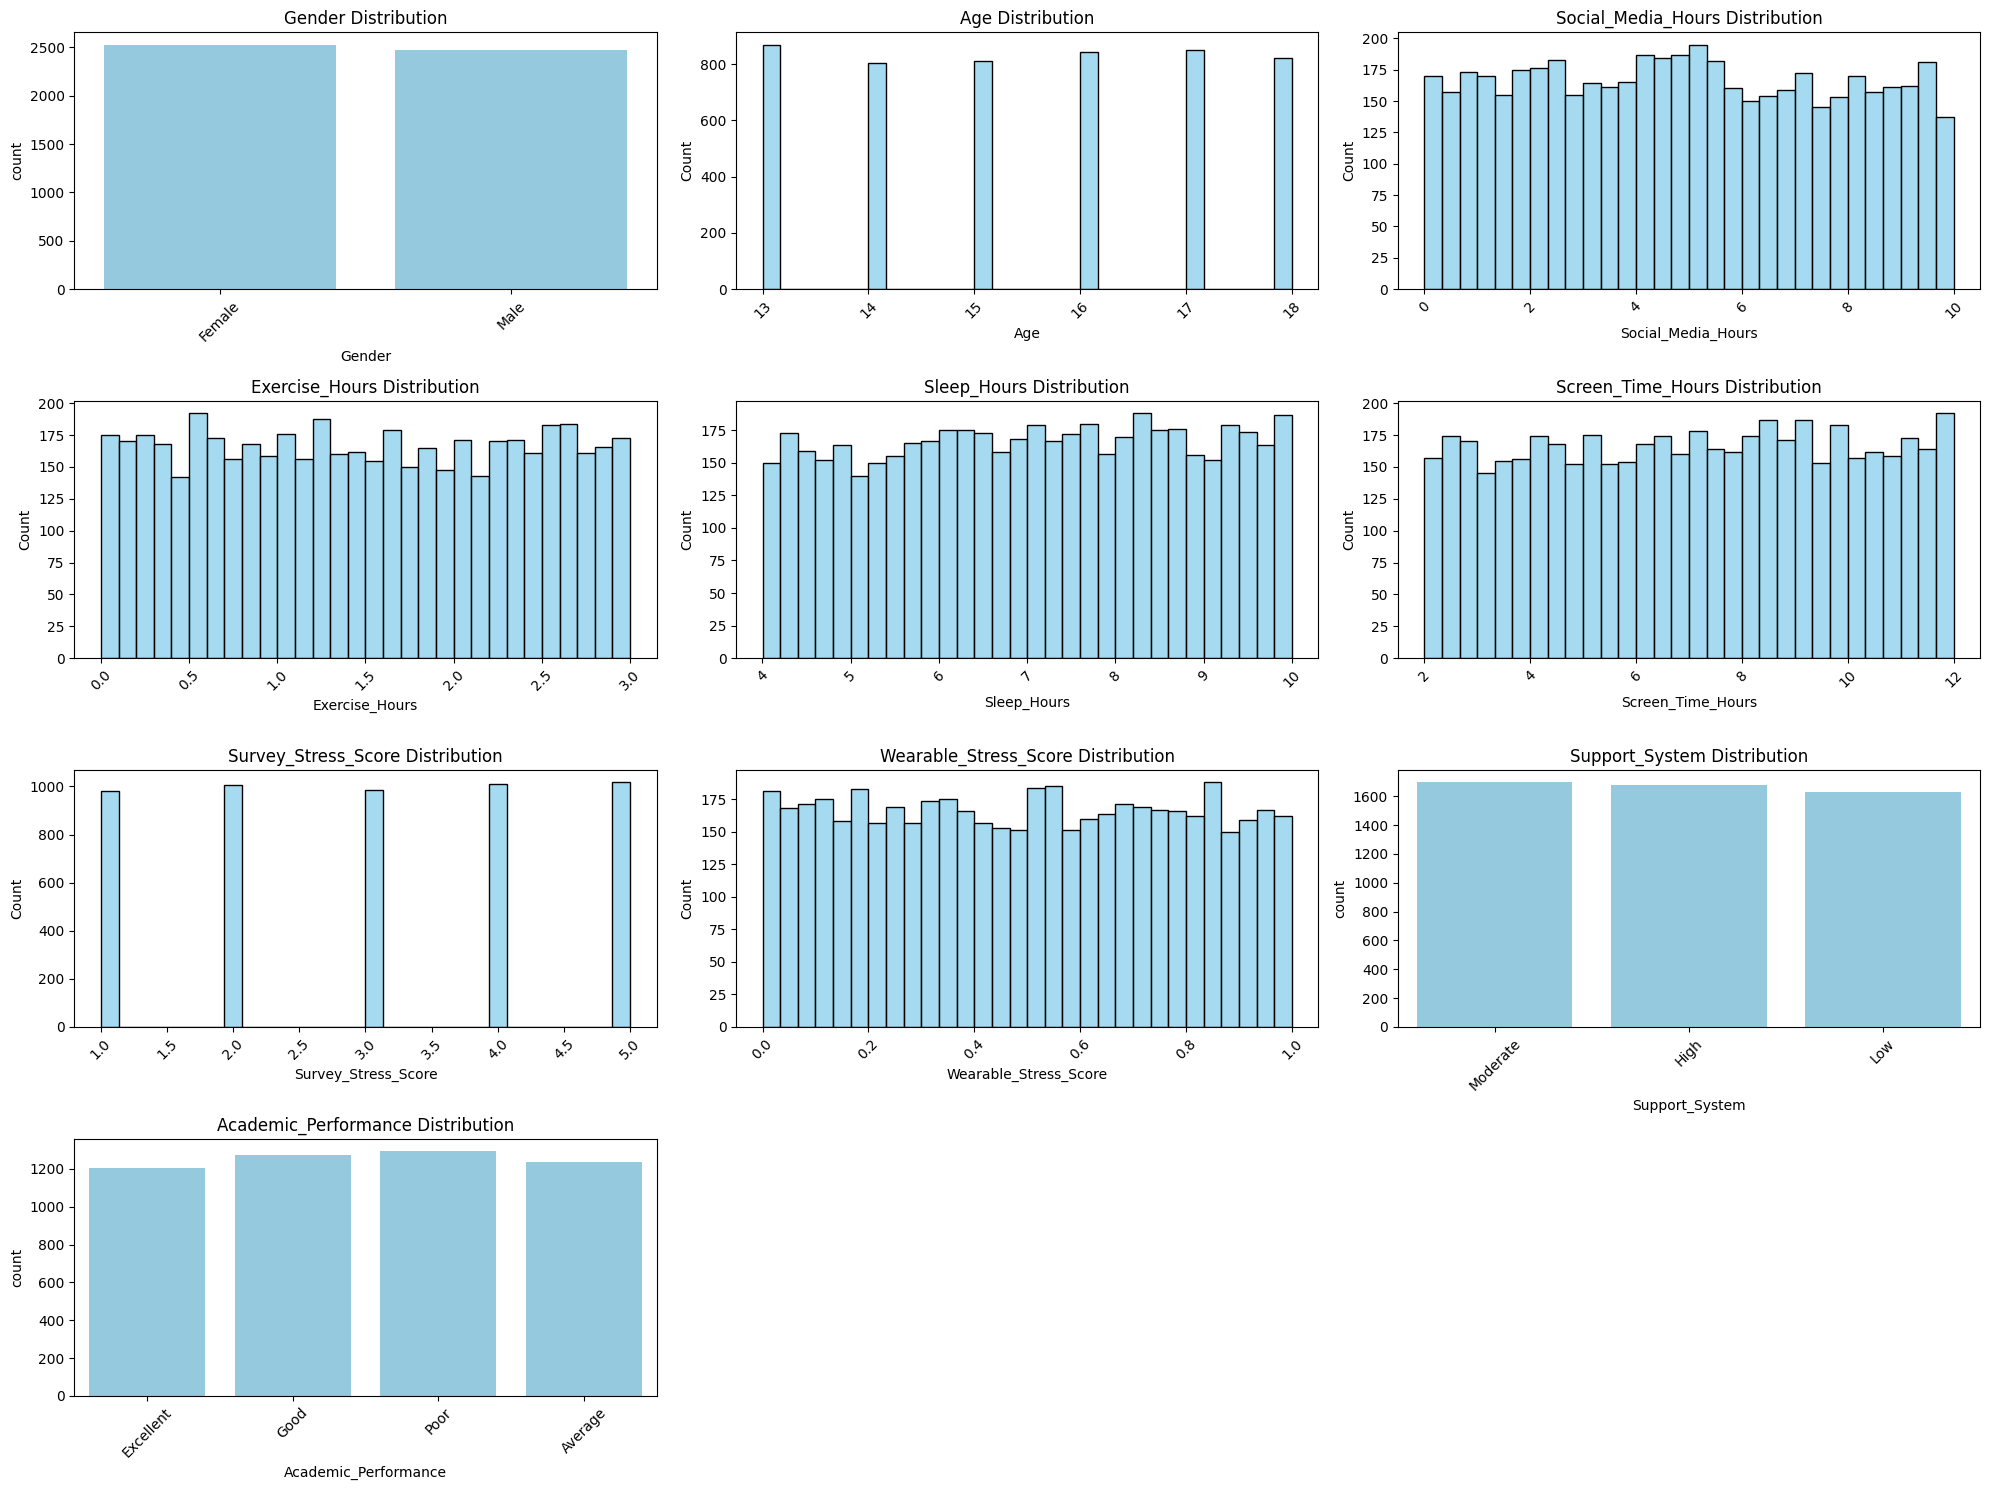

In [34]:
DS['Gender'] = DS['Gender'].replace({'F': 'Female', 'M': 'Male'})

features_basic = [
    "Gender",
    "Age",
    "Social_Media_Hours",
    "Exercise_Hours",
    "Sleep_Hours",
    "Screen_Time_Hours",
    "Survey_Stress_Score",
    "Wearable_Stress_Score",
    "Support_System",
    "Academic_Performance"
]

plt.figure(figsize=(20, 15))

for i, feature in enumerate(features_basic, 1):
    plt.subplot(4, 3, i) 
    if DS[feature].dtype == 'object':
        sns.countplot(data=DS, x=feature, color='skyblue')
    else:
        sns.histplot(data=DS, x=feature, bins=30, kde=False, color='skyblue')
    plt.title(f'{feature} Distribution')
    plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()


<span style="color: turquoise; font-size: 15px;">The dataset displays a fairly balanced gender distribution between male and female students. The age distribution spans from 13 to 18 years old, with relatively even representation across these ages. Social media hours, exercise hours, sleep hours, and screen time all exhibit relatively uniform distributions, although there is some natural variance in usage patterns. Notably, survey stress scores are almost evenly distributed across scores from 1 to 5, while wearable stress scores appear uniformly distributed from 0 to 1, suggesting the scoring system is evenly spread. For support system, the distribution is also well-balanced between "Low", "Moderate", and "High" categories. Meanwhile, academic performance is consistently spread among "Excellent", "Good", "Poor", and "Average", which shows a healthy diversity in academic results. Overall, the dataset shows a balanced and comprehensive representation of student experiences and wellbeing metrics, making it a strong foundation for predictive analysis.</span>

In [50]:
Gender_Distribution = DataSet.groupby('Gender')['Gender'].value_counts().sort_index().rename("Count").to_frame()

Gender_Distribution

,Count
Gender,
F,2528
M,2472


In [49]:
Age_Frequency = DataSet['Age'].value_counts().sort_index().rename("Count").to_frame()

Age_Frequency

,Count
Age,
13,870
14,803
15,812
16,842
17,852
18,821


In [48]:
DataSet['Support_System'] = pd.Categorical(
    DataSet['Support_System'],                
    categories=['Low', 'Moderate', 'High'], 
    ordered=True
)
Support_Frequency = DataSet['Support_System'].value_counts(sort=False).rename("Count").to_frame()
Support_Frequency

,Count
Support_System,
Low,1627
Moderate,1696
High,1677


In [47]:
SSS_Frequency = DataSet['Survey_Stress_Score'].value_counts().sort_index().rename("Count").to_frame()

SSS_Frequency

,Count
Survey_Stress_Score,
1,981
2,1004
3,987
4,1011
5,1017


In [45]:
DataSet['Academic_Performance'] = pd.Categorical(
    DataSet['Academic_Performance'],
    categories=['Poor', 'Average', 'Good', 'Excellent'],
    ordered=True
)

AP_Frequency = DataSet['Academic_Performance'].value_counts(sort=False).rename("Count").to_frame()

AP_Frequency

,Count
Academic_Performance,
Poor,1293
Average,1234
Good,1271
Excellent,1202


In [68]:
bins = list(range(0, 11)) + [DS['Social_Media_Hours'].max() + 1]

labels = [f'{i}–{i+1} hrs' for i in range(0, 10)] + ['10+ hrs']

DS['Social_Media_Bin'] = pd.cut(DS['Social_Media_Hours'], bins=bins, labels=labels, include_lowest=True)

Social_Media_Bin_Distribution = DS['Social_Media_Bin'].value_counts().sort_index().rename("Count").to_frame()
Social_Media_Bin_Distribution

,Count
Social_Media_Bin,
0–1 hrs,500
1–2 hrs,500
2–3 hrs,514
3–4 hrs,490
4–5 hrs,558
5–6 hrs,537
6–7 hrs,464
7–8 hrs,470
8–9 hrs,489


In [58]:
exercise_bins = [0, 1.5, 2, 2.5, 3]
exercise_labels = ['0–1.5 hrs', '1.5–2 hrs', '2–2.5 hrs', '2.5–3 hrs']

DS['Exercise_Hours_Bin'] = pd.cut(DS['Exercise_Hours'], bins=exercise_bins, labels=exercise_labels, include_lowest=True)

Exercise_Bin_Distribution = DS['Exercise_Hours_Bin'].value_counts().sort_index().rename("Count").to_frame()
Exercise_Bin_Distribution

,Count
Exercise_Hours_Bin,
0–1.5 hrs,2520
1.5–2 hrs,797
2–2.5 hrs,816
2.5–3 hrs,867


In [55]:
min_sleep = int(DS['Sleep_Hours'].min())
max_sleep = int(np.ceil(DS['Sleep_Hours'].max())) + 1

sleep_bins = np.arange(min_sleep, max_sleep + 1, 1)

sleep_labels = [f'{i}–{i+1} hrs' for i in range(min_sleep, max_sleep)]

DS['Sleep_Hours_Bin'] = pd.cut(DS['Sleep_Hours'], bins=sleep_bins, labels=sleep_labels, include_lowest=True)

Sleep_Bin_Distribution = DS['Sleep_Hours_Bin'].value_counts().sort_index().rename("Count").to_frame()
Sleep_Bin_Distribution

,Count
Sleep_Hours_Bin,
4–5 hrs,796
5–6 hrs,778
6–7 hrs,850
7–8 hrs,855
8–9 hrs,865
9–10 hrs,856
10–11 hrs,0


In [79]:
max_screen = DS['Screen_Time_Hours'].max()
upper_limit_screen = max(10, round(max_screen + 1)) 

screen_bins = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, upper_limit_screen]
screen_labels = [
    '0–2 hrs', '2–3 hrs', '3–4 hrs', '4–5 hrs', '5–6 hrs',
    '6–7 hrs', '7–8 hrs', '8–9 hrs', '9–10 hrs', '10+ hrs'
]

DS['Screen_Time_Bin'] = pd.cut(DS['Screen_Time_Hours'], bins=screen_bins, labels=screen_labels, include_lowest=True)

Screen_Bin_Distribution = DS['Screen_Time_Bin'].value_counts().sort_index().rename("Count").to_frame()
Screen_Bin_Distribution

,Count
Screen_Time_Bin,
0–2 hrs,0
2–3 hrs,501
3–4 hrs,455
4–5 hrs,495
5–6 hrs,482
6–7 hrs,501
7–8 hrs,504
8–9 hrs,532
9–10 hrs,523


In [80]:
wearable_bins = np.linspace(0, 1, 6) 
wearable_labels = ['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']

DS['Wearable_Stress_Bin'] = pd.cut(DS['Wearable_Stress_Score'], bins=wearable_bins, labels=wearable_labels, include_lowest=True)

Wearable_Bin_Distribution = DS['Wearable_Stress_Bin'].value_counts().sort_index().rename("Count").to_frame()
Wearable_Bin_Distribution

,Count
Wearable_Stress_Bin,
0–0.2,1036
0.2–0.4,998
0.4–0.6,981
0.6–0.8,997
0.8–1.0,988


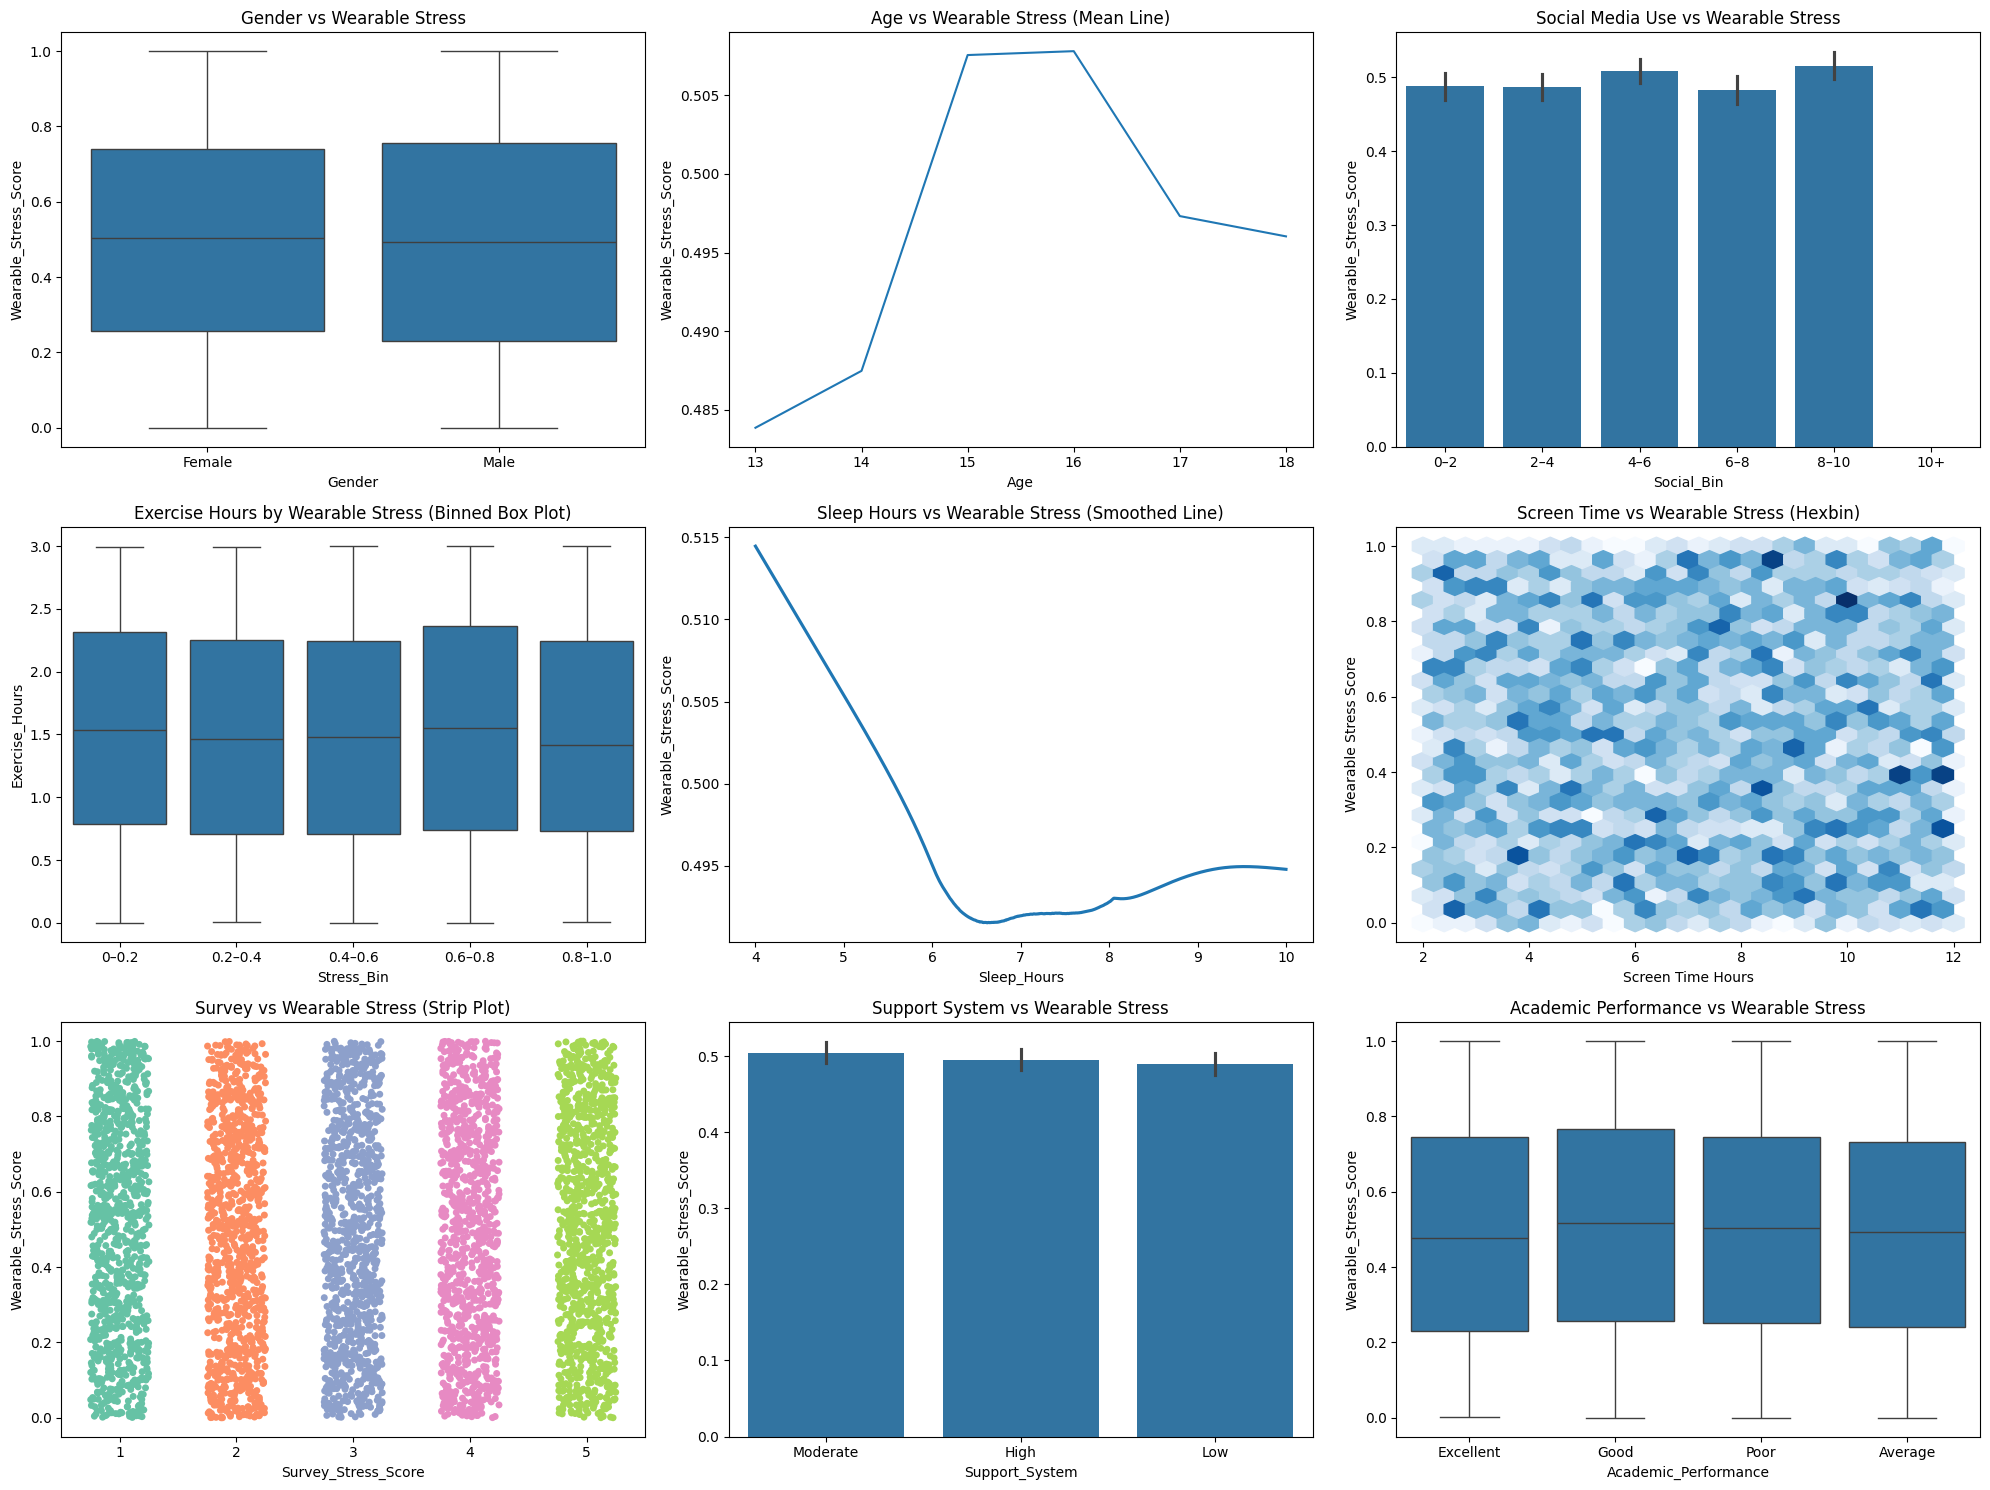

In [104]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))
axes = axes.flatten()

sns.boxplot(x='Gender', y='Wearable_Stress_Score', data=DS, ax=axes[0])
axes[0].set_title("Gender vs Wearable Stress")

age_group = DS.groupby('Age')['Wearable_Stress_Score'].mean().reset_index()
sns.lineplot(x='Age', y='Wearable_Stress_Score', data=age_group, ax=axes[1])
axes[1].set_title("Age vs Wearable Stress (Mean Line)")

final_bin_edge = max(11, round(DS['Social_Media_Hours'].max() + 1))
DS['Social_Bin'] = pd.cut(
    DS['Social_Media_Hours'],
    bins=[0, 2, 4, 6, 8, 10, final_bin_edge],
    labels=['0–2', '2–4', '4–6', '6–8', '8–10', '10+'],
    include_lowest=True
)

sns.barplot(x='Social_Bin', y='Wearable_Stress_Score', data=DS, ax=axes[2], estimator=np.mean)
axes[2].set_title("Social Media Use vs Wearable Stress")

stress_bins = np.linspace(0, 1, 6)
stress_labels = ['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']
DS['Stress_Bin'] = pd.cut(DS['Wearable_Stress_Score'], bins=stress_bins, labels=stress_labels)

sns.boxplot(x='Stress_Bin', y='Exercise_Hours', data=DS, ax=axes[3])
axes[3].set_title("Exercise Hours by Wearable Stress (Binned Box Plot)")

sns.regplot(x='Sleep_Hours', y='Wearable_Stress_Score', data=DS, ax=axes[4], scatter=False, lowess=True)
axes[4].set_title("Sleep Hours vs Wearable Stress (Smoothed Line)")

axes[5].hexbin(x=DS['Screen_Time_Hours'], y=DS['Wearable_Stress_Score'], gridsize=25, cmap='Blues')
axes[5].set_title("Screen Time vs Wearable Stress (Hexbin)")
axes[5].set_xlabel("Screen Time Hours")
axes[5].set_ylabel("Wearable Stress Score")

sns.stripplot(
    x='Survey_Stress_Score', 
    y='Wearable_Stress_Score', 
    data=DS, 
    ax=axes[6], 
    jitter=0.25, 
    hue='Survey_Stress_Score', 
    palette='Set2', 
    dodge=False,
    legend=False
)
axes[6].set_title("Survey vs Wearable Stress (Strip Plot)")

sns.barplot(x='Support_System', y='Wearable_Stress_Score', data=DS, ax=axes[7], estimator=np.mean)
axes[7].set_title("Support System vs Wearable Stress")

sns.boxplot(x='Academic_Performance', y='Wearable_Stress_Score', data=DS, ax=axes[8])
axes[8].set_title("Academic Performance vs Wearable Stress")

plt.tight_layout()
plt.show()

<span style="color: turquoise; font-size: 20px;">The visualizations reveal that wearable stress levels are relatively consistent across different variables, showing only slight variation. Gender does not significantly influence stress levels, as both males and females show similar score distributions. Age shows a mild increase in stress around 15–16 years old, then slightly drops. Social media usage and screen time do not show a strong linear relationship with stress, although slight increases are visible at higher usage bins. Sleep hours show a minor inverse trend—lower sleep slightly correlates with higher stress—while exercise hours remain evenly distributed across stress bins. The survey stress score, support system, and academic performance show minimal differences in wearable stress levels, though students with lower support and poorer academic outcomes appear to trend toward marginally higher stress. Overall, no single variable dominates as a clear predictor visually, indicating that stress may result from a complex interaction of lifestyle and psychological factors.</span>

In [92]:
wearable_bins = np.linspace(0, 1, 6) 
wearable_labels = ['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']

DS['Wearable_Stress_Bin'] = pd.cut(DS['Wearable_Stress_Score'], bins=wearable_bins, labels=wearable_labels, include_lowest=True)

Wearable_Bin_Distribution = DS.groupby(['Wearable_Stress_Bin', 'Gender'], observed=False).size().unstack().fillna(0).astype(int)
Wearable_Bin_Distribution.index.name = 'wearable stress'

Wearable_Bin_Distribution

Gender,Female,Male
wearable stress,,
0–0.2,490,546
0.2–0.4,525,473
0.4–0.6,497,484
0.6–0.8,529,468
0.8–1.0,487,501


In [93]:
wearable_bins = np.linspace(0, 1, 6) 
wearable_labels = ['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']

DS['Wearable_Stress_Bin'] = pd.cut(DS['Wearable_Stress_Score'], bins=wearable_bins, labels=wearable_labels, include_lowest=True)

Wearable_Bin_Distribution = DS.groupby(['Wearable_Stress_Bin', 'Age'], observed=False).size().unstack().fillna(0).astype(int)
Wearable_Bin_Distribution.index.name = 'wearable stress'

Wearable_Bin_Distribution

Age,13,14,15,16,17,18
wearable stress,,,,,,
0–0.2,187,183,166,159,170,171
0.2–0.4,189,152,153,166,171,167
0.4–0.6,168,154,159,170,175,155
0.6–0.8,164,156,151,180,174,172
0.8–1.0,162,158,183,167,162,156


In [99]:
DataSet['Support_System'] = pd.Categorical(
    DataSet['Support_System'],                
    categories=['Low', 'Moderate', 'High'], 
    ordered=True
)
wearable_bins = np.linspace(0, 1, 6) 
wearable_labels = ['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']

DS['Wearable_Stress_Bin'] = pd.cut(DS['Wearable_Stress_Score'], bins=wearable_bins, labels=wearable_labels, include_lowest=True)

Wearable_Bin_Distribution = DS.groupby(
    ['Wearable_Stress_Bin', 'Support_System'],
    observed=False
).size().unstack().fillna(0).astype(int)

Wearable_Bin_Distribution.index.name = 'wearable stress'

Wearable_Bin_Distribution = Wearable_Bin_Distribution[['Low', 'Moderate', 'High']]

Wearable_Bin_Distribution

Support_System,Low,Moderate,High
wearable stress,,,
0–0.2,348,352,336
0.2–0.4,326,318,354
0.4–0.6,319,347,315
0.6–0.8,316,327,354
0.8–1.0,318,352,318


In [97]:
wearable_bins = np.linspace(0, 1, 6) 
wearable_labels = ['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']

DS['Wearable_Stress_Bin'] = pd.cut(DS['Wearable_Stress_Score'], bins=wearable_bins, labels=wearable_labels, include_lowest=True)

Wearable_Bin_Distribution = DS.groupby(['Wearable_Stress_Bin', 'Survey_Stress_Score'], observed=False).size().unstack().fillna(0).astype(int)
Wearable_Bin_Distribution.index.name = 'wearable stress'

Wearable_Bin_Distribution

Survey_Stress_Score,1,2,3,4,5
wearable stress,,,,,
0–0.2,201,230,206,206,193
0.2–0.4,180,190,208,220,200
0.4–0.6,195,197,191,196,202
0.6–0.8,200,206,192,194,205
0.8–1.0,205,181,190,195,217


In [100]:
DataSet['Academic_Performance'] = pd.Categorical(
    DataSet['Academic_Performance'],
    categories=['Poor', 'Average', 'Good', 'Excellent'],
    ordered=True
)
wearable_bins = np.linspace(0, 1, 6) 
wearable_labels = ['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']

DS['Wearable_Stress_Bin'] = pd.cut(DS['Wearable_Stress_Score'], bins=wearable_bins, labels=wearable_labels, include_lowest=True)

Wearable_Bin_Distribution = DS.groupby(
    ['Wearable_Stress_Bin', 'Academic_Performance'],
    observed=False
).size().unstack().fillna(0).astype(int)

Wearable_Bin_Distribution.index.name = 'wearable stress'

Wearable_Bin_Distribution = Wearable_Bin_Distribution[['Poor', 'Average', 'Good', 'Excellent']]

Wearable_Bin_Distribution

Academic_Performance,Poor,Average,Good,Excellent
wearable stress,,,,
0–0.2,263,246,256,271
0.2–0.4,252,266,233,247
0.4–0.6,256,245,255,225
0.6–0.8,266,244,251,236
0.8–1.0,256,233,276,223


In [105]:
bins = list(range(0, 11)) + [DS['Social_Media_Hours'].max() + 1]

labels = [f'{i}–{i+1} hrs' for i in range(0, 10)] + ['10+ hrs']

DS['Social_Media_Bin'] = pd.cut(DS['Social_Media_Hours'], bins=bins, labels=labels, include_lowest=True)

wearable_bins = np.linspace(0, 1, 6) 
wearable_labels = ['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']

DS['Wearable_Stress_Bin'] = pd.cut(DS['Wearable_Stress_Score'], bins=wearable_bins, labels=wearable_labels, include_lowest=True)

Wearable_Bin_Distribution = DS.groupby(['Wearable_Stress_Bin', 'Social_Media_Bin'], observed=False).size().unstack().fillna(0).astype(int)
Wearable_Bin_Distribution.index.name = 'wearable stress'

Wearable_Bin_Distribution

Social_Media_Bin,0–1 hrs,1–2 hrs,2–3 hrs,3–4 hrs,4–5 hrs,5–6 hrs,6–7 hrs,7–8 hrs,8–9 hrs,9–10 hrs,10+ hrs
wearable stress,,,,,,,,,,,
0–0.2,106,94,111,118,96,113,102,110,89,97,0
0.2–0.4,103,109,101,96,104,114,86,108,87,90,0
0.4–0.6,105,98,98,90,121,101,92,72,105,99,0
0.6–0.8,102,104,108,92,108,112,91,95,99,86,0
0.8–1.0,84,95,96,94,129,97,93,85,109,106,0


In [106]:
exercise_bins = [0, 1.5, 2, 2.5, 3]
exercise_labels = ['0–1.5 hrs', '1.5–2 hrs', '2–2.5 hrs', '2.5–3 hrs']

DS['Exercise_Hours_Bin'] = pd.cut(DS['Exercise_Hours'], bins=exercise_bins, labels=exercise_labels, include_lowest=True)

wearable_bins = np.linspace(0, 1, 6) 
wearable_labels = ['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']

DS['Wearable_Stress_Bin'] = pd.cut(DS['Wearable_Stress_Score'], bins=wearable_bins, labels=wearable_labels, include_lowest=True)

Wearable_Bin_Distribution = DS.groupby(['Wearable_Stress_Bin', 'Exercise_Hours_Bin'], observed=False).size().unstack().fillna(0).astype(int)
Wearable_Bin_Distribution.index.name = 'wearable stress'

Wearable_Bin_Distribution

Exercise_Hours_Bin,0–1.5 hrs,1.5–2 hrs,2–2.5 hrs,2.5–3 hrs
wearable stress,,,,
0–0.2,504,176,162,194
0.2–0.4,510,164,177,147
0.4–0.6,496,161,165,159
0.6–0.8,484,149,162,202
0.8–1.0,526,147,150,165


In [107]:
min_sleep = int(DS['Sleep_Hours'].min())
max_sleep = int(np.ceil(DS['Sleep_Hours'].max())) + 1

sleep_bins = np.arange(min_sleep, max_sleep + 1, 1)

sleep_labels = [f'{i}–{i+1} hrs' for i in range(min_sleep, max_sleep)]

DS['Sleep_Hours_Bin'] = pd.cut(DS['Sleep_Hours'], bins=sleep_bins, labels=sleep_labels, include_lowest=True)

Wearable_Bin_Distribution = DS.groupby(['Wearable_Stress_Bin', 'Sleep_Hours_Bin'], observed=False).size().unstack().fillna(0).astype(int)
Wearable_Bin_Distribution.index.name = 'wearable stress'

Wearable_Bin_Distribution

Sleep_Hours_Bin,4–5 hrs,5–6 hrs,6–7 hrs,7–8 hrs,8–9 hrs,9–10 hrs,10–11 hrs
wearable stress,,,,,,,
0–0.2,163,154,174,189,171,185,0
0.2–0.4,140,158,177,167,194,162,0
0.4–0.6,155,162,160,161,165,178,0
0.6–0.8,168,171,170,170,151,167,0
0.8–1.0,170,133,169,168,184,164,0


In [108]:
max_screen = DS['Screen_Time_Hours'].max()
upper_limit_screen = max(10, round(max_screen + 1)) 

screen_bins = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, upper_limit_screen]
screen_labels = [
    '0–2 hrs', '2–3 hrs', '3–4 hrs', '4–5 hrs', '5–6 hrs',
    '6–7 hrs', '7–8 hrs', '8–9 hrs', '9–10 hrs', '10+ hrs'
]

DS['Screen_Time_Bin'] = pd.cut(DS['Screen_Time_Hours'], bins=screen_bins, labels=screen_labels, include_lowest=True)

Wearable_Bin_Distribution = DS.groupby(['Wearable_Stress_Bin', 'Screen_Time_Bin'], observed=False).size().unstack().fillna(0).astype(int)
Wearable_Bin_Distribution.index.name = 'wearable stress'

Wearable_Bin_Distribution

Screen_Time_Bin,0–2 hrs,2–3 hrs,3–4 hrs,4–5 hrs,5–6 hrs,6–7 hrs,7–8 hrs,8–9 hrs,9–10 hrs,10+ hrs
wearable stress,,,,,,,,,,
0–0.2,0,95,104,87,102,100,111,116,120,201
0.2–0.4,0,102,92,100,91,109,90,102,92,220
0.4–0.6,0,92,78,116,101,97,88,107,107,195
0.6–0.8,0,111,93,96,100,94,107,94,100,202
0.8–1.0,0,101,88,96,88,101,108,113,104,189


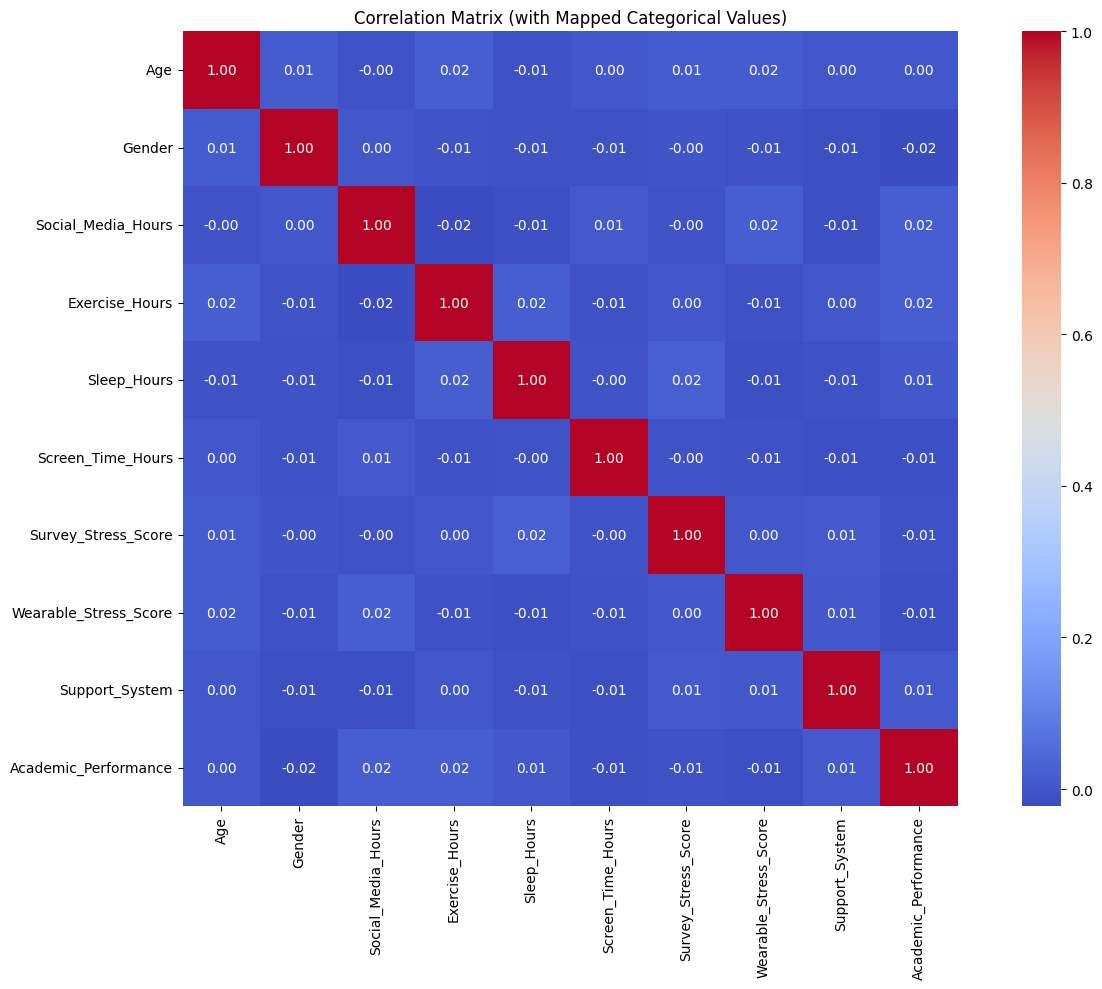

In [100]:
DS_temp = DS.copy()

academic_map = {'Poor': 1, 'Average': 2, 'Good': 3, 'Excellent': 4}
support_map = {'Low': 1, 'Moderate': 2, 'High': 3}
gender_map = {'Female': 0, 'Male': 1}

DS_temp['Academic_Performance'] = DS_temp['Academic_Performance'].map(academic_map)
DS_temp['Support_System'] = DS_temp['Support_System'].map(support_map)
DS_temp['Gender'] = DS_temp['Gender'].str.strip().str.upper().map({'F': 0, 'M': 1, 'FEMALE': 0, 'MALE': 1})

columns_to_drop = [col for col in DS_temp.columns if 'Bin' in col or col == 'User_ID']
DS_temp_clean = DS_temp.drop(columns=columns_to_drop)

corr_temp = DS_temp_clean.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_temp, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix (with Mapped Categorical Values)")
plt.tight_layout()
plt.show()

<span style="color: turquoise; font-size: 15px;">The correlation matrix above reveals that there are no strong linear relationships among the variables in the dataset, as most correlation values hover near 0. This includes the target variable, Wearable_Stress_Score, which shows only very weak correlations with other features such as Age, Gender, Social_Media_Hours, Sleep_Hours, and Academic_Performance. While some might expect variables like Sleep or Exercise to show a stronger inverse relationship with stress, the data indicates that stress levels—at least as measured by wearable devices—are influenced more subtly or perhaps by other unmeasured factors. The diagonal red line (with a correlation of 1.00) confirms each variable's perfect correlation with itself, serving as a helpful visual anchor. Overall, this matrix suggests that stress is likely a complex outcome not easily explained by any single factor in this dataset, and a multivariate or non-linear modeling approach may be more effective in predictive analysis.</span>


### IV. Feature Engineering

<span style="color: turquoise; font-size: 20px;">1. Fix Social Media vs Screen Time conflict</span>

In [101]:
DS['Social_Media_Capped'] = np.where(
    DS['Social_Media_Hours'] > DS['Screen_Time_Hours'],
    DS['Screen_Time_Hours'],
    DS['Social_Media_Hours']
)

DS['Social_vs_Screen_Conflict'] = np.where(
    DS['Social_Media_Hours'] > DS['Screen_Time_Hours'],
    1, 0
)

<span style="color: turquoise; font-size: 20px;">2. Create Interaction Features</span>

In [102]:
DS['Sleep_Exercise_Balance'] = DS['Sleep_Hours'] / (DS['Exercise_Hours'] + 1)
DS['Stress_Gap'] = DS['Survey_Stress_Score'] - DS['Wearable_Stress_Score']
DS['Social_Media_Percentage'] = DS['Social_Media_Hours'] / (DS['Screen_Time_Hours'] + 1e-5) 

<span style="color: turquoise; font-size: 20px;">3. Binning Continuous Features</span>

In [103]:
wearable_bins = np.linspace(0, 1, 6)
wearable_labels = ['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']
DS['Wearable_Stress_Bin'] = pd.cut(DS['Wearable_Stress_Score'], bins=wearable_bins, labels=wearable_labels, include_lowest=True)

In [104]:
social_bins = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
social_labels = ['0–2 hrs', '2–3 hrs', '3–4 hrs', '4–5 hrs', '5–6 hrs', '6–7 hrs', '7–8 hrs', '8–9 hrs', '9–10 hrs', '10+ hrs']
DS['Social_Bin'] = pd.cut(DS['Social_Media_Hours'], bins=social_bins, labels=social_labels, include_lowest=True)

In [105]:
exercise_bins = np.arange(0, 4.5, 0.5)
exercise_labels = [f'{exercise_bins[i]}–{exercise_bins[i+1]}' for i in range(len(exercise_bins)-1)]
DS['Exercise_Bin'] = pd.cut(DS['Exercise_Hours'], bins=exercise_bins, labels=exercise_labels, include_lowest=True)


In [106]:
sleep_max = int(np.ceil(DS['Sleep_Hours'].max()))
sleep_bins = list(range(4, sleep_max + 2))
sleep_labels = [f'{i}–{i+1}' for i in range(4, sleep_max + 1)]
DS['Sleep_Bin'] = pd.cut(DS['Sleep_Hours'], bins=sleep_bins, labels=sleep_labels, include_lowest=True)

In [107]:
screen_max = int(np.ceil(DS['Screen_Time_Hours'].max()))
screen_bins = list(range(0, screen_max + 2))
screen_labels = [f'{i}–{i+1}' for i in range(screen_max + 1)]
DS['Screen_Bin'] = pd.cut(DS['Screen_Time_Hours'], bins=screen_bins, labels=screen_labels, include_lowest=True)

<span style="color: turquoise; font-size: 20px;">4. Encode Categorical Columns</span>

In [108]:
DS['Gender_Mapped'] = DS['Gender'].map({'F': 0, 'M': 1})

In [109]:
support_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
DS['Support_System_Mapped'] = DS['Support_System'].map(support_mapping)

In [110]:
academic_mapping = {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}
DS['Academic_Performance_Mapped'] = DS['Academic_Performance'].map(academic_mapping)

<span style="color: turquoise; font-size: 20px;">5. Normalize Continuous Features (Min-Max)</span>

In [111]:
scaler = MinMaxScaler()
columns_to_scale = ['Age', 'Social_Media_Hours', 'Exercise_Hours', 'Sleep_Hours', 'Screen_Time_Hours']
DS[[col + '_Scaled' for col in columns_to_scale]] = scaler.fit_transform(DS[columns_to_scale])

In [112]:
DS

,User_ID,Age,Gender,Social_Media_Hours,Exercise_Hours,Sleep_Hours,Screen_Time_Hours,Survey_Stress_Score,Wearable_Stress_Score,Support_System,...,Sleep_Bin,Screen_Bin,Gender_Mapped,Support_System_Mapped,Academic_Performance_Mapped,Age_Scaled,Social_Media_Hours_Scaled,Exercise_Hours_Scaled,Sleep_Hours_Scaled,Screen_Time_Hours_Scaled
0,1,16,F,9.654486,2.458001,5.198926,8.158189,3,0.288962,Moderate,...,5–6,8–9,0,1,3,0.6,0.965925,0.819367,0.199645,0.615861
1,2,17,M,9.158143,0.392095,8.866097,5.151993,5,0.409446,Moderate,...,8–9,5–6,1,1,2,0.8,0.916263,0.130571,0.811073,0.315198
2,3,15,M,5.028755,0.520119,4.943095,9.209325,2,0.423837,Moderate,...,4–5,9–10,1,1,0,0.4,0.503098,0.173256,0.156990,0.720991
3,4,17,F,7.951103,1.022630,5.262773,9.823658,5,0.666021,Moderate,...,5–6,9–10,0,1,1,0.8,0.795493,0.340798,0.210290,0.782433
4,5,17,F,1.357459,1.225462,6.196080,11.338990,5,0.928060,High,...,6–7,11–12,0,2,0,0.8,0.135767,0.408425,0.365900,0.933988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,14,M,0.088148,1.003339,8.684888,5.922202,1,0.750205,Moderate,...,8–9,5–6,1,1,1,0.2,0.008767,0.334366,0.780860,0.392230
4996,4997,15,F,7.161276,1.024644,5.312684,10.224924,4,0.427209,Moderate,...,5–6,10–11,0,1,3,0.4,0.716467,0.341470,0.218612,0.822565
4997,4998,14,M,3.444383,2.877972,9.227726,4.059322,4,0.002893,High,...,9–10,4–5,1,2,2,0.2,0.344574,0.959390,0.871367,0.205914
4998,4999,18,F,7.866525,2.395839,4.317831,10.657076,2,0.612063,High,...,4–5,10–11,0,2,1,1.0,0.787031,0.798641,0.052739,0.865787


### V. Modeling

In [113]:
DS['Wearable_Stress_Bin'] = pd.cut(DS['Wearable_Stress_Score'], bins=np.linspace(0, 1, 6),
                                   labels=['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0'], include_lowest=True)
y_clf = LabelEncoder().fit_transform(DS['Wearable_Stress_Bin'])

In [114]:
feature_cols = [
    'Age', 'Gender_Mapped', 'Support_System_Mapped', 'Academic_Performance_Mapped',
    'Social_Media_Hours', 'Exercise_Hours', 'Sleep_Hours', 'Screen_Time_Hours',
    'Social_vs_Screen_Conflict', 'Sleep_Exercise_Balance', 'Stress_Gap', 'Social_Media_Percentage'
]
X = DS[feature_cols]

In [115]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

In [116]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_clf, y_train_clf)
y_pred_tree = tree_model.predict(X_test_clf)
tree_report = classification_report(y_test_clf, y_pred_tree, output_dict=True)

In [117]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_clf, y_train_clf)
y_pred_rf = rf_model.predict(X_test_clf)
rf_report = classification_report(y_test_clf, y_pred_rf, output_dict=True)

In [118]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_clf, y_train_clf)
y_pred_gb = gb_model.predict(X_test_clf)
gb_report = classification_report(y_test_clf, y_pred_gb, output_dict=True)

In [119]:
dataframe=pd.DataFrame(gb_report)
dataframe

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.994819,1.000000,1.0,1.0,1.0,0.999,0.998964,0.999005
recall,1.000000,0.995074,1.0,1.0,1.0,0.999,0.999015,0.999000
f1-score,0.997403,0.997531,1.0,1.0,1.0,0.999,0.998987,0.999000
support,192.000000,203.000000,207.0,201.0,197.0,0.999,1000.000000,1000.000000


### VI. Evaluation

In [120]:
conf_matrix = confusion_matrix(y_test_clf, y_pred_gb)

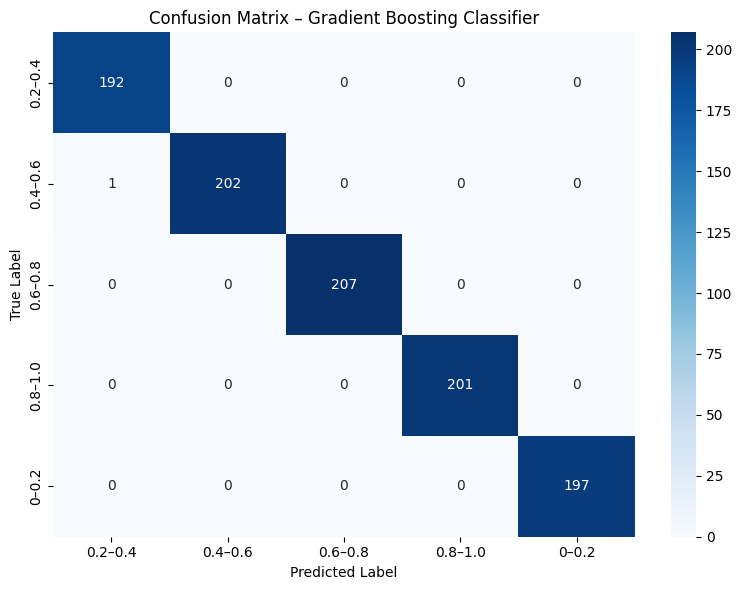

In [121]:
wearable_labels = ['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']
le = LabelEncoder()
le.fit(wearable_labels)

plt.figure(figsize=(8, 6)) 
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Gradient Boosting Classifier")
plt.tight_layout()
plt.show()

<span style="color: turquoise; font-size: 15px;">The confusion matrix for the Gradient Boosting Classifier shows near-perfect performance across all wearable stress score bins. Each bin (0–0.2 to 0.8–1.0) was accurately predicted with only one minor misclassification out of 1000 samples. This indicates that the model is extremely effective at distinguishing between different levels of wearable stress, with a 99.9% accuracy rate, and excellent consistency across all classes.</span>

### VII. Conclusion

<span style="color: turquoise; font-size: 15px;">

This study explored the prediction of student stress levels using behavioral, lifestyle, and support-related features gathered from both self-reported data and wearable devices. After thorough preprocessing and feature engineering, both regression and classification models were implemented to analyze stress trends, with particular focus on the `Wearable_Stress_Score` as the target for predictive analysis.

Among all models tested, the **Gradient Boosting Classifier** achieved the highest accuracy (99.9%) in classifying students into wearable stress score bins, closely followed by the **Decision Tree** and **Random Forest** models. The confusion matrix further confirmed the model’s strength, showing only one misclassification across 1000 test samples. While impressive, such near-perfect results warrant caution, as they may indicate **overfitting**, especially in the absence of validation on completely unseen data.

On the other hand, the **Linear Regression model** performed poorly, explaining only ~4% of the variance in the continuous stress scores. This suggests that while exact score prediction is complex and possibly non-linear, categorizing stress levels is more achievable with the given features.

**Recommendation:**  
- **Feature Importance Analysis** should be conducted next to understand what drives stress prediction.  
- **Cross-validation** should be introduced to confirm model generalizability and detect overfitting.  
- Additional data such as emotional indicators, academic load, or screen content could enhance the prediction power.  
- Future implementations may benefit from shifting fully into classification models over regression when working with stress indicators like wearable scores.

</span>


### Testing

In [124]:
sample_data = pd.DataFrame([{
    'Age': 17,
    'Gender_Mapped': 1,
    'Support_System_Mapped': 0,
    'Academic_Performance_Mapped': 0,
    'Social_Media_Hours': 7.5,
    'Exercise_Hours': 0.3,
    'Sleep_Hours': 4.5,
    'Screen_Time_Hours': 10.0,
    'Social_vs_Screen_Conflict': 1, 
    'Sleep_Exercise_Balance': 4.5 / (0.3 + 1), 
    'Stress_Gap': 4 - 0.6, 
    'Social_Media_Percentage': 7.5 / (10.0 + 1e-5) 
}])

predicted_bin = custom_prediction[0]


if predicted_bin == 0:
    stress_range = '0–0.2'
    stress_level = 'Very Low'
    comment = 'This person is experiencing very low stress.'
elif predicted_bin == 1:
    stress_range = '0.2–0.4'
    stress_level = 'Low'
    comment = 'This person is calm and only mildly stressed.'
elif predicted_bin == 2:
    stress_range = '0.4–0.6'
    stress_level = 'Moderate'
    comment = 'This person has a moderate level of stress. Not alarming, but worth monitoring.'
elif predicted_bin == 3:
    stress_range = '0.6–0.8'
    stress_level = 'High'
    comment = 'This person is under high stress. It may be affecting their health or focus.'
elif predicted_bin == 4:
    stress_range = '0.8–1.0'
    stress_level = 'Very High'
    comment = 'This person is extremely stressed and may need immediate support or intervention.'
else:
    stress_range = 'Unknown'
    stress_level = 'Unknown'
    comment = 'Prediction could not be interpreted.'

print(f"Predicted Wearable Stress Bin: {stress_range} ({stress_level})")
print(f"Insight: {comment}")

Predicted Wearable Stress Bin: 0–0.2 (Very Low)
Insight: This person is experiencing very low stress.


**Which means:**

Regardless of this individual's low academic achievements and negative lifestyle choices, the data from the wearable device indicates they are currently **not exhibiting elevated stress indicators**— or at least not within the detectable range of the wearable sensor/model.

**This might hint at:**

-  *Stress response latency*
-  *Robust coping mechanisms*
-  *A shortcoming in the model with regard to the data utilized*